In [29]:
import pandas as pd

df = pd.read_csv("customer_churn_data.csv")

In [30]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [31]:
import numpy as np

# Remove Customer ID
df = df.drop("customerID", axis=1)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Convert target variable
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

df.head()

C:\Users\22053\AppData\Local\Temp\ipykernel_752\582667879.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,Yes,23,No,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,0
1,Female,0,Yes,No,43,No,No phone service,DSL,Yes,No,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,1
2,Male,1,No,No,51,Yes,No,DSL,No,Yes,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,1
3,Male,1,No,No,72,Yes,Yes,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,0
4,Male,1,No,No,25,Yes,Yes,DSL,No,No,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,1


In [32]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Hyperparameter Sensitivity

In [36]:
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

In [37]:
depth_values = [3,5,10,15,20,None]

train_scores = []
test_scores = []
cv_scores = []

for depth in depth_values:

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42,
            n_estimators=200,
            max_depth=depth
        ))
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_scores.append(f1_score(y_train, train_pred))
    test_scores.append(f1_score(y_test, test_pred))

    cv = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    ).mean()

    cv_scores.append(cv)

In [39]:
depth_table = pd.DataFrame({
    "Max Depth": depth_values,
    "Train F1": train_scores,
    "Test F1": test_scores,
    "CV F1": cv_scores
})

In [40]:
depth_table

,Max Depth,Train F1,Test F1,CV F1
0,3.0,0.415621,0.323766,0.352833
1,5.0,0.612075,0.414946,0.410078
2,10.0,0.968462,0.478145,0.466899
3,15.0,1.000000,0.481255,0.479472
4,20.0,1.000000,0.488576,0.472481
5,NaN,1.000000,0.461538,0.473988


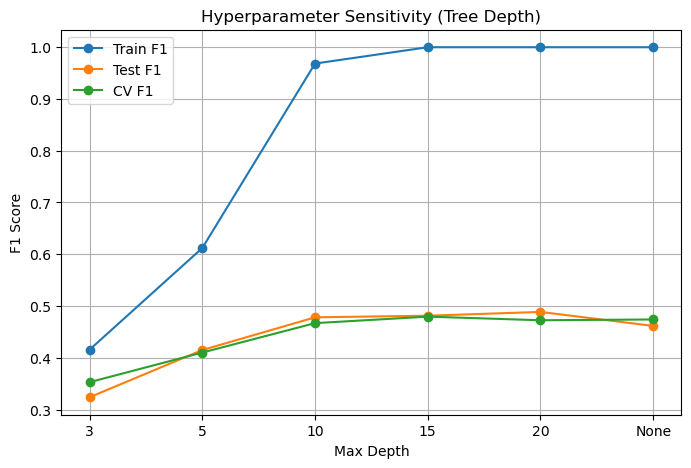

In [41]:
plt.figure(figsize=(8,5))

plt.plot(
    [str(i) for i in depth_values],
    train_scores,
    marker="o",
    label="Train F1"
)

plt.plot(
    [str(i) for i in depth_values],
    test_scores,
    marker="o",
    label="Test F1"
)

plt.plot(
    [str(i) for i in depth_values],
    cv_scores,
    marker="o",
    label="CV F1"
)

plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.title("Hyperparameter Sensitivity (Tree Depth)")
plt.legend()

plt.grid(True)
plt.show()

In [42]:
trees = [50,100,200,300,500]

train_scores = []
test_scores = []
cv_scores = []

for n in trees:

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42,
            n_estimators=n,
            max_depth=10
        ))
    ])

    model.fit(X_train,y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_scores.append(f1_score(y_train,train_pred))
    test_scores.append(f1_score(y_test,test_pred))

    cv = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    ).mean()

    cv_scores.append(cv)

In [43]:
tree_table = pd.DataFrame({
    "Trees":trees,
    "Train F1":train_scores,
    "Test F1":test_scores,
    "CV F1":cv_scores
})

tree_table

,Trees,Train F1,Test F1,CV F1
0,50,0.947300,0.469442,0.475511
1,100,0.961944,0.491259,0.478906
2,200,0.968462,0.478145,0.466899
3,300,0.972694,0.464701,0.459291
4,500,0.974040,0.478603,0.465693


In [45]:
best_depth = depth_table.loc[
    depth_table["CV F1"].idxmax(),
    "Max Depth"
]

best_trees = tree_table.loc[
    tree_table["CV F1"].idxmax(),
    "Trees"
]

print("Best max_depth :", best_depth)
print("Best n_estimators :", best_trees)

Best max_depth : 15.0
Best n_estimators : 100


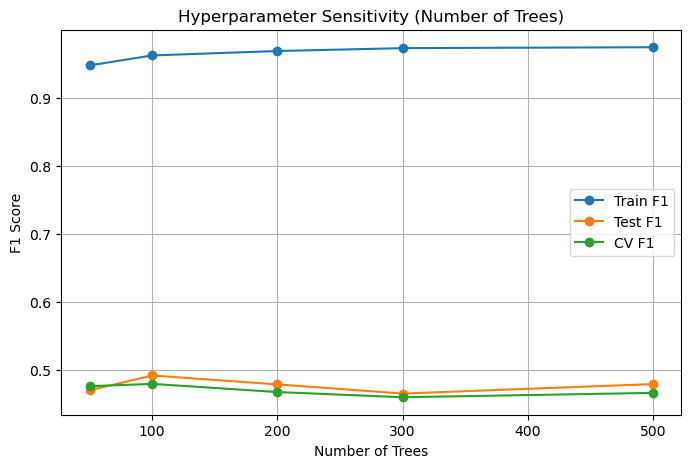

In [44]:
plt.figure(figsize=(8,5))

plt.plot(trees,train_scores,marker="o",label="Train F1")
plt.plot(trees,test_scores,marker="o",label="Test F1")
plt.plot(trees,cv_scores,marker="o",label="CV F1")

plt.xlabel("Number of Trees")
plt.ylabel("F1 Score")
plt.title("Hyperparameter Sensitivity (Number of Trees)")
plt.legend()
plt.grid(True)

plt.show()

In [46]:
depth_table["Difference"] = depth_table["Train F1"] - depth_table["Test F1"]

display(depth_table)

,Max Depth,Train F1,Test F1,CV F1,Difference
0,3.0,0.415621,0.323766,0.352833,0.091856
1,5.0,0.612075,0.414946,0.410078,0.197129
2,10.0,0.968462,0.478145,0.466899,0.490317
3,15.0,1.000000,0.481255,0.479472,0.518745
4,20.0,1.000000,0.488576,0.472481,0.511424
5,NaN,1.000000,0.461538,0.473988,0.538462


In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=10
    ))
])

best_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
optimized_predictions = best_model.predict(X_test)

optimized_probabilities = best_model.predict_proba(X_test)[:,1]

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [50]:
print("Optimized Random Forest Performance")
print("-"*40)

print("Accuracy :", accuracy_score(y_test, optimized_predictions))
print("Precision:", precision_score(y_test, optimized_predictions))
print("Recall   :", recall_score(y_test, optimized_predictions))
print("F1 Score :", f1_score(y_test, optimized_predictions))
print("ROC AUC  :", roc_auc_score(y_test, optimized_probabilities))

Optimized Random Forest Performance
----------------------------------------
Accuracy : 0.5025510204081632
Precision: 0.4953789279112754
Recall   : 0.46206896551724136
F1 Score : 0.47814451382694023
ROC AUC  : 0.4966095811154825


In [51]:
print(classification_report(y_test, optimized_predictions))

              precision    recall  f1-score   support

           0       0.51      0.54      0.52       596
           1       0.50      0.46      0.48       580

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.50      1176
weighted avg       0.50      0.50      0.50      1176



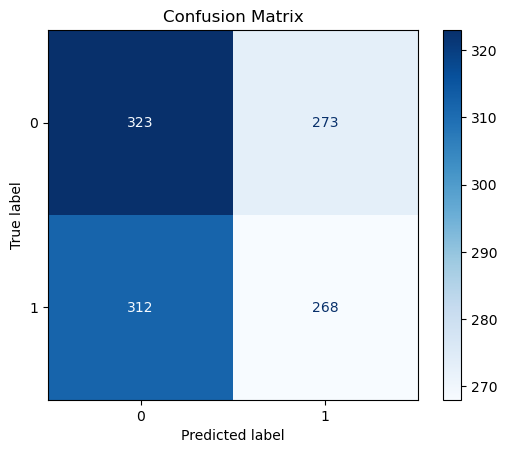

In [52]:
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    optimized_predictions,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

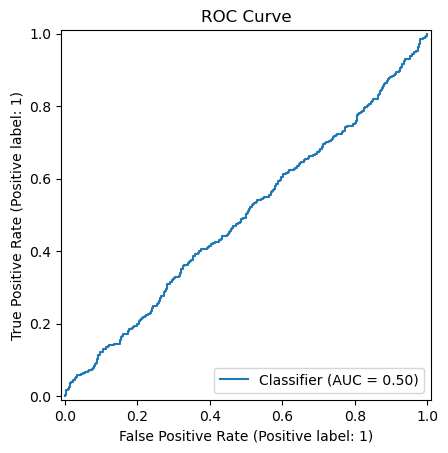

In [53]:
RocCurveDisplay.from_predictions(
    y_test,
    optimized_probabilities
)

plt.title("ROC Curve")
plt.show()

In [54]:
performance = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Score":[
        accuracy_score(y_test, optimized_predictions),
        precision_score(y_test, optimized_predictions),
        recall_score(y_test, optimized_predictions),
        f1_score(y_test, optimized_predictions),
        roc_auc_score(y_test, optimized_probabilities)
    ]
})

performance

,Metric,Score
0,Accuracy,0.502551
1,Precision,0.495379
2,Recall,0.462069
3,F1 Score,0.478145
4,ROC AUC,0.496610


In [57]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
baseline_predictions = baseline_model.predict(X_test)
baseline_probabilities = baseline_model.predict_proba(X_test)[:, 1]

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_precision = precision_score(y_test, baseline_predictions)
baseline_recall = recall_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions)
baseline_auc = roc_auc_score(y_test, baseline_probabilities)

print("Baseline Accuracy :", baseline_accuracy)
print("Baseline Precision:", baseline_precision)
print("Baseline Recall   :", baseline_recall)
print("Baseline F1 Score :", baseline_f1)
print("Baseline ROC AUC  :", baseline_auc)

Baseline Accuracy : 0.5051020408163265
Baseline Precision: 0.49818840579710144
Baseline Recall   : 0.47413793103448276
Baseline F1 Score : 0.48586572438162545
Baseline ROC AUC  : 0.500837479750058


In [60]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_auc
    ],
    "Optimized": [
        accuracy_score(y_test, optimized_predictions),
        precision_score(y_test, optimized_predictions),
        recall_score(y_test, optimized_predictions),
        f1_score(y_test, optimized_predictions),
        roc_auc_score(y_test, optimized_probabilities)
    ]
})

comparison

,Metric,Baseline,Optimized
0,Accuracy,0.505102,0.502551
1,Precision,0.498188,0.495379
2,Recall,0.474138,0.462069
3,F1 Score,0.485866,0.478145
4,ROC AUC,0.500837,0.496610


In [61]:
RandomForestClassifier(
    random_state=42,
    n_estimators=200,
    max_depth=10
)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Conclusion

> 1. Increasing max_depth initially improves model performance
   because the model captures more complex relationships.

> 2. Very large tree depths may lead to overfitting,
   where training performance improves but testing
   performance decreases.

> 3. Increasing the number of trees improves stability
   and reduces variance.

> 4. After a certain number of trees, performance
   improves very little while training time increases.

> 5. Compare Train F1 and Test F1.
   A large gap indicates overfitting.